In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False

df=pd.read_csv('教务通知.csv',encoding='utf-8-sig')

In [11]:
def number(x):
    s=str(x)
    if ';' in s:
        parts=s.split(';')
        total=sum(int(p.strip())for p in parts)
        return total
    else:
        return int(s)

df['总下载次数']=df['附件下载次数'].apply(number)
df['日期']=pd.to_datetime(df['日期'])
df['月份']=df['日期'].dt.month
df['通知人']=df['通知人'].str.replace('[【】]', '', regex=True)

In [12]:
count=df['通知人'].value_counts()
prop=df['通知人'].value_counts(normalize=True)*100
result=pd.DataFrame({
    '通知数量':count,
    '通知占比':prop.round(2)
})
print('通知人发布通知的情况：')
result

通知人发布通知的情况：


,通知数量,通知占比
通知人,,
教学运行,161,32.2
实践科,114,22.8
质量办,68,13.6
计划科,48,9.6
综合科,34,6.8
教材中心,32,6.4
教研教改,31,6.2
教学通知,8,1.6
电教中心,4,0.8


In [14]:
average=df.groupby('通知人')['总下载次数'].mean().sort_values(ascending=False)
total=df.groupby('通知人')['总下载次数'].sum().sort_values(ascending=False)
print('附件下载次数与通知人的关系')
result_df=pd.DataFrame({
    '通知人':average.index,
    '平均下载次数':average.values,
    '总下载次数':total
})
result_df

附件下载次数与通知人的关系


,通知人,平均下载次数,总下载次数
通知人,,,
实践科,教研教改,1286.064516,114395
教学运行,计划科,1155.750000,110076
计划科,实践科,1003.464912,55476
教研教改,教学运行,683.701863,39868
质量办,教学通知,653.750000,35576
教材中心,教材中心,644.812500,20634
教学通知,质量办,523.176471,5230
综合科,综合科,71.176471,2420
电教中心,电教中心,0.000000,0


In [15]:
counts=df['月份'].value_counts().sort_index()
print('各月发布通知的数量：')
for month in range(1,13):
    cnt=counts.get(month,0)
    print(f"{month}月：{cnt}条")
max_month=counts.idxmax()
print(f"通知发布最高峰：{max_month}月")

各月发布通知的数量：
1月：34条
2月：21条
3月：51条
4月：82条
5月：67条
6月：51条
7月：10条
8月：14条
9月：68条
10月：23条
11月：32条
12月：47条
通知发布最高峰：4月


In [7]:
keywords=['考试','竞赛','选课','毕业','教材','期末','报名','成绩']
results=[]
for kw in keywords:
    mask=df['标题'].str.contains(kw,na=False)
    avg=df[mask]['总下载次数'].mean()
    count=mask.sum()
    results.append({'关键词':kw,'出现次数：':count,'平均下载次数':avg})
keyword_df=pd.DataFrame(results)
keyword_df

,关键词,出现次数：,平均下载次数
0,考试,89,734.640449
1,竞赛,39,247.358974
2,选课,31,1204.451613
3,毕业,28,1550.107143
4,教材,32,655.187500
5,期末,72,666.027778
6,报名,3,0.000000
7,成绩,4,3140.000000


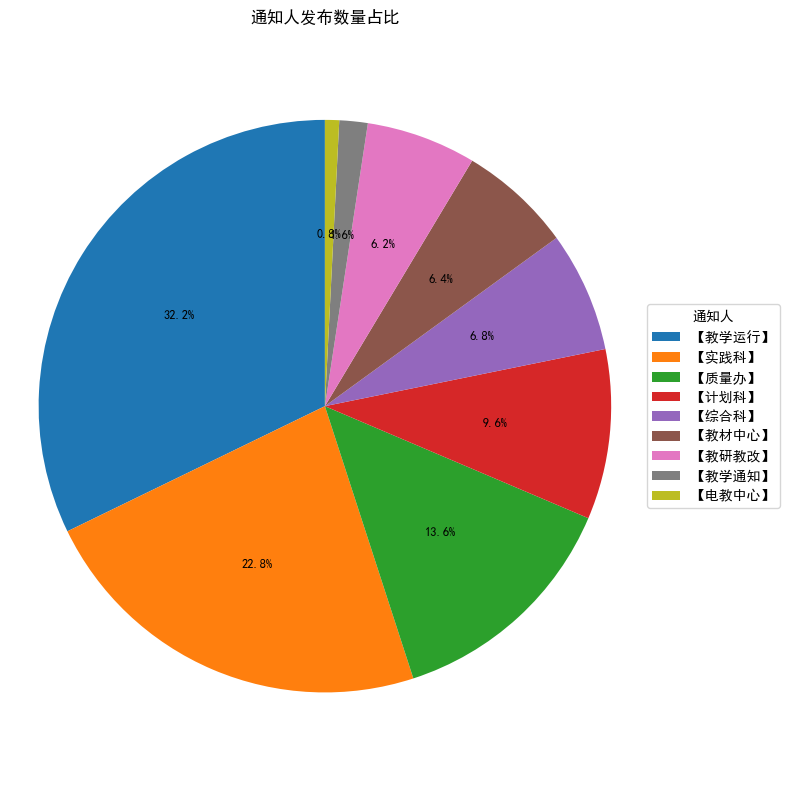

In [42]:
plt.figure(figsize=(8,8))
wedges, texts, autotexts = plt.pie(result['通知数量'], autopct='%1.1f%%', startangle=90,textprops={'fontsize': 9})
plt.title('通知人发布数量占比')
plt.axis('equal')
plt.legend(wedges, result.index, title="通知人", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.tight_layout()
plt.show()

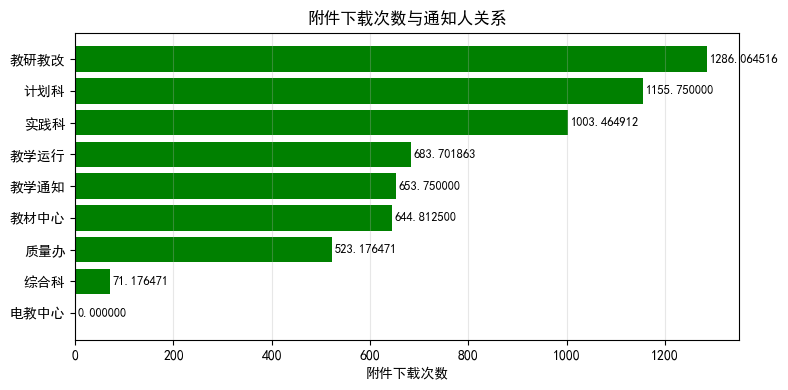

In [16]:
plt.figure(figsize=(8,4))
sorted_ave=average.sort_values(ascending=True)
bars=plt.barh(range(len(sorted_ave)),sorted_ave.values,color='green')
plt.yticks(range(len(sorted_ave)),sorted_ave.index)
plt.xlabel('附件下载次数')
plt.title('附件下载次数与通知人关系')
for i,(bar,value)in enumerate(zip(bars,sorted_ave.values)):
    width=bar.get_width()
    plt.text(width+5,bar.get_y()+bar.get_height()/2,f'{value:0f}',ha='left',va='center',fontsize=9)
plt.grid(axis='x',alpha=0.3)
plt.tight_layout()
plt.show()    

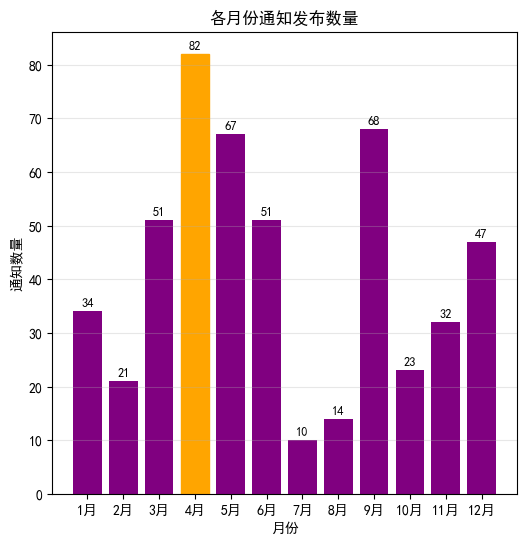

In [ ]:
plt.figure(figsize=(6,6))
months=list(range(1,13))
month_cnt=[counts.get(month,0)for month in months]
bars=plt.bar(months,month_cnt,color='purple')
plt.xlabel('月份')
plt.ylabel('通知数量')
plt.title('各月份通知发布数量')
plt.xticks(months,[f'{m}月' for m in months])
for i,(bar,count) in enumerate(zip(bars,month_cnt)):
    plt.text(bar.get_x()+bar.get_width()/2,count+0.5,f'{int(count)}',ha='center',va='bottom',fontsize=9)
 
if max_month in months:
    max_idx=months.index(max_month)
    bars[max_idx].set_color('orange')   
plt.grid(axis='y',alpha=0.3)
plt.show()   